# How Wrong Is Your MMM?

Marketing Mix Models are only as reliable as the data they're trained on. When TV, Meta, and Search spend all move together — because they're driven by the same planning cycle — the model can't tell them apart. The result: marginal return estimates that swing wildly depending on which period of data you happened to use.

This notebook quantifies that problem using three channels (TV, Meta, Search) with known true marginal returns, so we can measure exactly how far off the model is — and how much that depends on inter-channel correlation.

**Two sections:**
1. **Sweep correlation** — as inter-channel correlation increases, how unreliable do the estimates become?
2. **Fixed correlation, many seeds** — at a realistic correlation of 0.7, how different would your marginal return estimates be if you'd run the MMM in a slightly different period?

**Section 3** (run the diagnostic on your own spend data) follows in the next sprint.


In [1]:
# config
FAST_MODE = False  # set False for publication-quality runs (50 sims per level)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from how_wrong_is_your_mmm import (
    CollinearityDiagnostic,
    simulate_spend,
    simulate_sales,
    fit_ols,
)

## The setup

Three channels: **TV**, **Meta**, and **Search**. In a real business, all three budgets tend to move together — when demand forecasts rise, all go up; when they fall, all get cut. We model this with a latent demand signal that drives spend in all channels.

True marginal returns: TV = 0.3, Meta = 0.5, Search = 0.4. We simulate sales as:

```
sales = base + 0.3 × TV + 0.5 × Meta + 0.4 × Search + noise
```

Then we fit OLS and ask: does it recover 0.3, 0.5, and 0.4? And how does the answer change as the channels become more correlated?


In [3]:
# single run at correlation 0.7 to show the setup
spend = simulate_spend(n_obs=104, correlation=0.7, seed=0)
print(
    f"Mean pairwise correlation: {spend.corr().to_numpy()[[0, 0, 1], [1, 2, 2]].mean():.2f}"
)
print()
for ch in spend.columns:
    print(
        f"{ch.upper():6s} spend range: £{spend[ch].min():,.0f} – £{spend[ch].max():,.0f}"
    )

Mean pairwise correlation: 0.69

TV     spend range: £52,159 – £153,003
META   spend range: £34,352 – £133,152
SEARCH spend range: £21,938 – £95,538


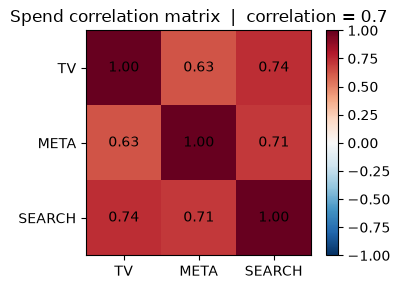

In [4]:
# show the correlation matrix
import matplotlib.pyplot as plt
import numpy as np

corr = spend.corr()
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels([c.upper() for c in corr.columns])
ax.set_yticklabels([c.upper() for c in corr.columns])
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title("Spend correlation matrix  |  correlation = 0.7")
plt.tight_layout()
plt.show()

## Section 1 — How bad does it get?

We run the same MMM across a range of correlation levels (0.1 → 0.9). At each level we simulate 50 different "periods" of data from the same market — same true marginal returns, different noise draws. The spread of estimates across those 50 periods tells us how unreliable the model is at that correlation level.

A tight distribution means the model gives consistent answers. A wide distribution means the answer you get depends heavily on which period you happened to use — which is not a property you want in a model you're using to set budgets.


In [5]:
n_sims = 10 if FAST_MODE else 50
correlations = np.round(np.arange(0.1, 0.95, 0.1), 1).tolist()

results = []
for corr in correlations:
    diag = CollinearityDiagnostic(correlation=corr, spend_seed=0)
    diag.fit(n_sims=n_sims, fast_mode=FAST_MODE)
    df = diag.results_.copy()
    df["target_correlation"] = corr
    df["actual_correlation"] = round(diag.actual_correlation, 2)
    results.append(df)

all_results = pd.concat(results, ignore_index=True)
print(f"Total simulations: {len(all_results)}")
all_results.head()

Total simulations: 1350


,sim,channel,true_marginal_return,estimated_marginal_return,error,error_pct,target_correlation,actual_correlation
0,0,tv,0.5,0.569471,0.069471,13.894297,0.1,0.11
1,0,meta,1.0,1.180522,0.180522,18.052236,0.1,0.11
2,0,search,1.5,1.656867,0.156867,10.457810,0.1,0.11
3,1,tv,0.5,0.515356,0.015356,3.071234,0.1,0.11
4,1,meta,1.0,0.956539,-0.043461,-4.346120,0.1,0.11


In [6]:
summary_rows = []
for corr in correlations:
    sub = all_results[all_results["target_correlation"] == corr]
    for ch in ["tv", "meta", "search"]:
        s = sub[sub["channel"] == ch]
        summary_rows.append(
            {
                "target_corr": corr,
                "channel": ch,
                "true": s["true_marginal_return"].iloc[0],
                "mean_est": s["estimated_marginal_return"].mean(),
                "std_est": s["estimated_marginal_return"].std(),
                "cv": s["estimated_marginal_return"].std()
                / abs(s["estimated_marginal_return"].mean()),
            }
        )

sweep_summary = pd.DataFrame(summary_rows).round(3)
print(sweep_summary.to_string(index=False))

 target_corr channel  true  mean_est  std_est    cv
         0.1      tv   0.5     0.508    0.038 0.075
         0.1    meta   1.0     1.001    0.052 0.052
         0.1  search   1.5     1.488    0.071 0.048
         0.2      tv   0.5     0.512    0.057 0.112
         0.2    meta   1.0     1.002    0.076 0.076
         0.2  search   1.5     1.482    0.106 0.072
         0.3      tv   0.5     0.516    0.074 0.143
         0.3    meta   1.0     1.002    0.095 0.095
         0.3  search   1.5     1.477    0.137 0.093
         0.4      tv   0.5     0.520    0.090 0.173
         0.4    meta   1.0     1.003    0.113 0.113
         0.4  search   1.5     1.471    0.167 0.114
         0.5      tv   0.5     0.525    0.107 0.204
         0.5    meta   1.0     1.003    0.133 0.133
         0.5  search   1.5     1.464    0.200 0.137
         0.6      tv   0.5     0.530    0.127 0.239
         0.6    meta   1.0     1.003    0.157 0.156
         0.6  search   1.5     1.456    0.239 0.164
         0.7

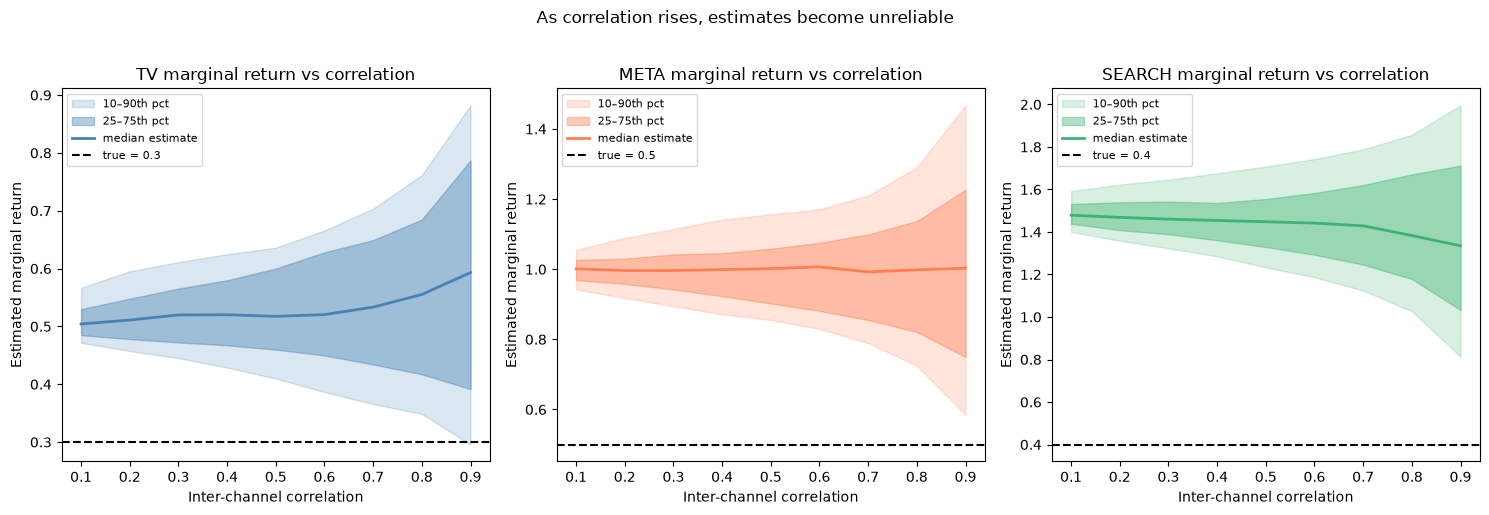

In [7]:
channels_cfg = [
    ("tv", 0.3, "steelblue"),
    ("meta", 0.5, "coral"),
    ("search", 0.4, "mediumseagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (channel, true_e, color) in zip(axes, channels_cfg):
    sub = all_results[all_results["channel"] == channel]

    medians = sub.groupby("target_correlation")["estimated_marginal_return"].median()
    q25 = sub.groupby("target_correlation")["estimated_marginal_return"].quantile(0.25)
    q75 = sub.groupby("target_correlation")["estimated_marginal_return"].quantile(0.75)
    q10 = sub.groupby("target_correlation")["estimated_marginal_return"].quantile(0.10)
    q90 = sub.groupby("target_correlation")["estimated_marginal_return"].quantile(0.90)

    ax.fill_between(correlations, q10, q90, alpha=0.2, color=color, label="10–90th pct")
    ax.fill_between(correlations, q25, q75, alpha=0.4, color=color, label="25–75th pct")
    ax.plot(correlations, medians, color=color, linewidth=2, label="median estimate")
    ax.axhline(
        true_e, color="black", linestyle="--", linewidth=1.5, label=f"true = {true_e}"
    )

    ax.set_xlabel("Inter-channel correlation")
    ax.set_ylabel("Estimated marginal return")
    ax.set_title(f"{channel.upper()} marginal return vs correlation")
    ax.legend(fontsize=8)

plt.suptitle("As correlation rises, estimates become unreliable", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**What this shows:** the median estimate stays close to the true value — OLS is unbiased. But the spread explodes as correlation increases. At correlation 0.9, the interquartile range is so wide that you could easily get an estimate that's double or half the true value, purely by chance.

This is the core problem: collinearity doesn't make the average wrong. It makes the answer unreliable. The model could tell you TV is your best channel, or your worst, depending on the data vintage — and both answers come from the same model on the same market.


## Section 2 — Your model could have said anything

Now we fix correlation at 0.7 — typical for two channels following the same campaign calendar — and run 50 different noise seeds. Each seed is a plausible alternative history: the same market, the same true marginal returns, but a slightly different period of data.

How different are the estimated marginal returns? This is the question every practitioner should ask before trusting an MMM output.


In [8]:
diag_fixed = CollinearityDiagnostic(correlation=0.7, spend_seed=0)
diag_fixed.fit(n_sims=n_sims, fast_mode=FAST_MODE)

print(f"Mean pairwise correlation: {diag_fixed.actual_correlation:.2f}")
print()
print(diag_fixed.summary().to_string(index=False))

Mean pairwise correlation: 0.69

channel  true_marginal_return  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta                   1.0          1.0034         0.1884          0.3410             0.1878
 search                   1.5          1.4445         0.2893         -3.7014             0.2003
     tv                   0.5          0.5378         0.1525          7.5556             0.2836


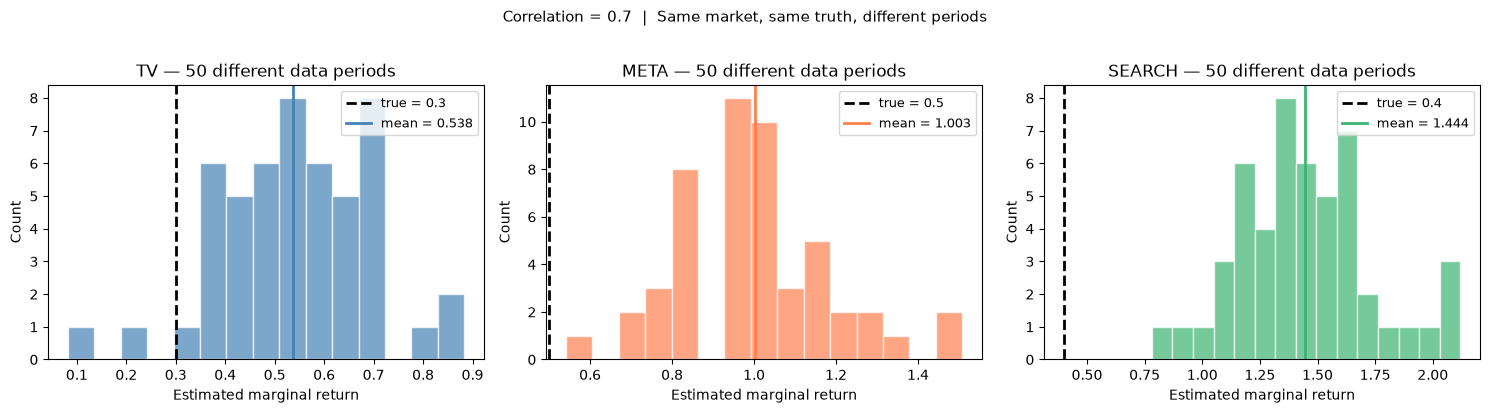

In [9]:
channels_cfg = [
    ("tv", 0.3, "steelblue"),
    ("meta", 0.5, "coral"),
    ("search", 0.4, "mediumseagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (channel, true_e, color) in zip(axes, channels_cfg):
    estimates = diag_fixed.results_[diag_fixed.results_["channel"] == channel][
        "estimated_marginal_return"
    ]

    ax.hist(estimates, bins=15, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(
        true_e, color="black", linestyle="--", linewidth=2, label=f"true = {true_e}"
    )
    ax.axvline(
        estimates.mean(),
        color=color,
        linestyle="-",
        linewidth=2,
        label=f"mean = {estimates.mean():.3f}",
    )

    ax.set_xlabel("Estimated marginal return")
    ax.set_ylabel("Count")
    ax.set_title(f"{channel.upper()} — {n_sims} different data periods")
    ax.legend(fontsize=9)

plt.suptitle(
    "Correlation = 0.7  |  Same market, same truth, different periods",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [10]:
true_marginal_returns = {"tv": 0.5, "meta": 1.0, "search": 1.5}
for channel, true_e in true_marginal_returns.items():
    estimates = diag_fixed.results_[diag_fixed.results_["channel"] == channel][
        "estimated_marginal_return"
    ]
    lo, hi = estimates.quantile(0.1), estimates.quantile(0.9)
    print(
        f"{channel.upper():6s}  true={true_e:.1f}  80% range: [{lo:.3f}, {hi:.3f}]  width={hi - lo:.3f}"
    )

TV      true=0.5  80% range: [0.366, 0.704]  width=0.338
META    true=1.0  80% range: [0.789, 1.210]  width=0.421
SEARCH  true=1.5  80% range: [1.124, 1.789]  width=0.664


**What this means in practice:** at correlation 0.7, your TV marginal return estimate has an 80% range that spans that entire interval. Refit the model next quarter with three more months of data and you'll likely get a different number — not because the market changed, but because the data was never informative enough to pin it down.

This is why MMM outputs shift every time you refit. It's not the model, and it's not the analyst. It's the data design.

**The fix:** deliberately vary the budget mix — more TV in some periods, more Meta in others. That de-correlates the channels and gives the model the variation it needs to tell them apart. That's the budget perturbation recommendation (next sprint).


## Section 3 — Your spend data

The diagnostic above uses synthetic spend. But the most useful version is personalised: run the same simulation on *your* actual channel spend, with *your* actual correlation structure.

When you pass your own spend DataFrame, we skip the synthetic spend generation entirely. We only simulate the sales column — applying known marginal returns to your real spend and adding noise. The collinearity in your data is already there; we're just quantifying how much it matters.

Below we demonstrate with a synthetic spend DataFrame passed in as if it were real. Swap it for your own data and the rest is identical.


In [11]:
# simulate a 'real' spend DataFrame — swap this for your actual data
real_spend = simulate_spend(n_obs=104, correlation=0.65, seed=7)
print(
    f"Spend DataFrame: {real_spend.shape[0]} weeks, channels: {list(real_spend.columns)}"
)
print(
    f"Mean pairwise correlation: {real_spend.corr().to_numpy()[[0, 0, 1], [1, 2, 2]].mean():.2f}"
)

Spend DataFrame: 104 weeks, channels: ['tv', 'meta', 'search']
Mean pairwise correlation: 0.65


In [12]:
# run the diagnostic on real spend
diag_real = CollinearityDiagnostic(
    spend_df=real_spend,
    true_marginal_returns={"tv": 0.5, "meta": 1.0, "search": 1.5},
)
diag_real.fit(n_sims=n_sims, fast_mode=FAST_MODE)

print(f"Mean pairwise correlation in your spend: {diag_real.actual_correlation:.2f}")
print()
print(diag_real.summary().to_string(index=False))

Mean pairwise correlation in your spend: 0.65

channel  true_marginal_return  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta                   1.0          0.9942         0.1917         -0.5792             0.1928
 search                   1.5          1.5684         0.2826          4.5628             0.1802
     tv                   0.5          0.5033         0.1694          0.6606             0.3366


In [13]:
for channel, true_e in {"tv": 0.5, "meta": 1.0, "search": 1.5}.items():
    estimates = diag_real.results_[diag_real.results_["channel"] == channel][
        "estimated_marginal_return"
    ]
    lo, hi = estimates.quantile(0.1), estimates.quantile(0.9)
    print(
        f"{channel.upper():6s}  true={true_e:.1f}  80% range: [{lo:.3f}, {hi:.3f}]  width={hi - lo:.3f}"
    )

TV      true=0.5  80% range: [0.279, 0.712]  width=0.433
META    true=1.0  80% range: [0.754, 1.199]  width=0.444
SEARCH  true=1.5  80% range: [1.224, 1.980]  width=0.756


The 80% range above is your personalised answer to *how wrong is your MMM*. It's not a generic warning about collinearity — it's a quantification of the unreliability in your specific spend data, given your specific correlation structure.

A narrower range means your channels are sufficiently de-correlated and your marginal return estimates are stable. A wide range means the budget mix hasn't varied enough to let the model distinguish individual channel effects — and the budget perturbation recommendation (next sprint) will show you what to do about it.


## Section 4 — Turning marginal return into £

An marginal return of 0.3 doesn't mean much to a CMO. Pass a `planned_spend` dict to `summary()` and the same simulated marginal return distribution gets rescaled into an incremental-revenue range: each simulated marginal return draw is multiplied by the planned spend for that channel, then the 10th–90th percentile is reported.

This assumes sales is already a £ value (revenue). For volume targets (signups, conversions), a `value_per_unit` (LTV-per-unit) parameter would be needed — out of scope for v1, see NOTES.md.


In [14]:
# translate marginal return into £ using a realistic plan-year spend split
planned_spend = {"tv": 5_100_000, "meta": 4_100_000, "search": 3_100_000}
print(diag_real.summary(planned_spend=planned_spend).to_string(index=False))

channel  true_marginal_return  mean_estimated  std_estimated  mean_error_pct  coef_of_variation  incremental_revenue_p10  incremental_revenue_p90
   meta                   1.0          0.9942         0.1917         -0.5792             0.1928             3093235.1315             4915149.0613
 search                   1.5          1.5684         0.2826          4.5628             0.1802             3795838.8368             6138710.4509
     tv                   0.5          0.5033         0.1694          0.6606             0.3366             1424471.8217             3633571.9302


The `incremental_revenue_p10`/`incremental_revenue_p90` columns are the same 80% range shown above for marginal return, just rescaled against your planned spend. This is the number that actually lands with a CMO: *"if you spend your planned budget on TV, the range of extra revenue we'd expect — purely from data unreliability, not model error — is £X to £Y."*

The range doesn't shrink on its own. That's what budget phasing (next sprint) is for.


### CAC and ROI, when sales means customers

`planned_spend` needs an absolute number to translate marginal return into £. `value_per_unit` doesn't — pass an average £ LTV per acquisition and `summary()` reports two channel properties directly from the marginal return distribution:

- **CAC** = `1 / marginal return` — £ spent per unit of sales (e.g. per signup)
- **ROI** = `marginal return * value_per_unit` — £ value back per £ spent

In this linear DGP, both are spend-independent: they don't scale with how much you plan to spend, only with how reliably the model has pinned down the channel's effect. Below, we reuse the same marginal returns from Sections 1–3 as if `sales` meant signups rather than £ revenue, purely to demonstrate the mechanic — treat the actual numbers as illustrative, not a real CAC/ROI estimate.

One honesty note: draws where the estimated marginal return lands near zero make CAC swing wildly (or go negative). That instability isn't a bug — it's the same unreliability the rest of this notebook is about, just viewed through a £ lens instead of an marginal return lens.


In [15]:
# treat sales as signups here, with an illustrative avg LTV per signup
value_per_unit = 150.0
ltv_summary = diag_real.summary(value_per_unit=value_per_unit)
print(ltv_summary.to_string(index=False))

channel  true_marginal_return  mean_estimated  std_estimated  mean_error_pct  coef_of_variation  cac_p10  cac_p90  roi_p10  roi_p90
   meta                   1.0          0.9942         0.1917         -0.5792             0.1928   0.8342   1.3256 113.1671 179.8225
 search                   1.5          1.5684         0.2826          4.5628             0.1802   0.5050   0.8167 183.6696 297.0344
     tv                   0.5          0.5033         0.1694          0.6606             0.3366   1.4047   3.5807  41.8962 106.8698


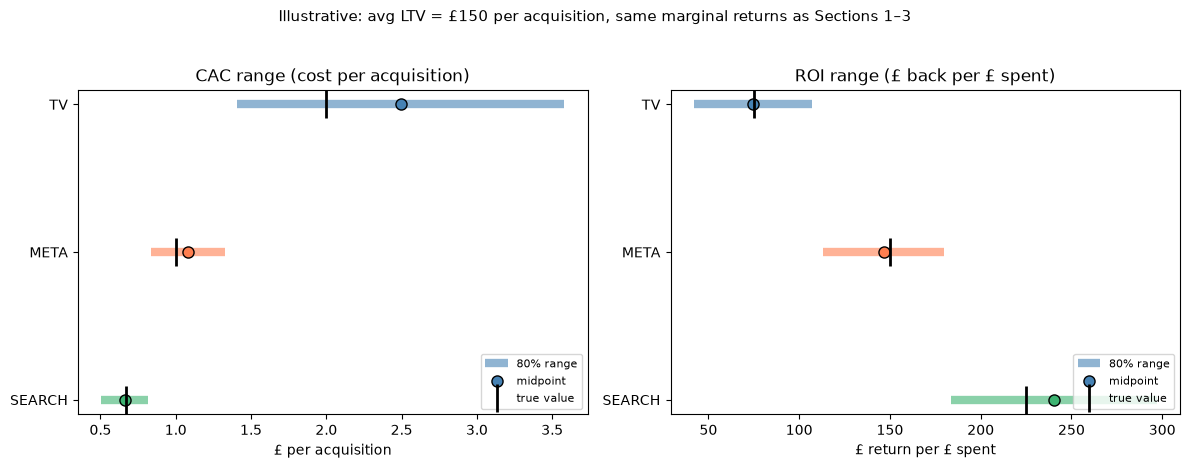

In [16]:
channels_cfg = [
    ("tv", "steelblue"),
    ("meta", "coral"),
    ("search", "mediumseagreen"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric, title, xlabel in zip(
    axes,
    ["cac", "roi"],
    ["CAC range (cost per acquisition)", "ROI range (\u00a3 back per \u00a3 spent)"],
    ["\u00a3 per acquisition", "\u00a3 return per \u00a3 spent"],
):
    for i, (channel, color) in enumerate(channels_cfg):
        row = ltv_summary[ltv_summary["channel"] == channel].iloc[0]
        lo, hi = row[f"{metric}_p10"], row[f"{metric}_p90"]
        mid = (lo + hi) / 2
        ax.plot(
            [lo, hi],
            [i, i],
            color=color,
            linewidth=6,
            alpha=0.6,
            solid_capstyle="butt",
            label="80% range" if i == 0 else None,
        )
        ax.plot(
            mid,
            i,
            "o",
            color=color,
            markersize=8,
            markeredgecolor="black",
            label="midpoint" if i == 0 else None,
        )
        true_e = row["true_marginal_return"]
        true_val = (1 / true_e) if metric == "cac" else (true_e * value_per_unit)
        ax.plot(
            true_val,
            i,
            "|",
            color="black",
            markersize=20,
            markeredgewidth=2,
            label="true value" if i == 0 else None,
        )
    ax.set_yticks(range(len(channels_cfg)))
    ax.set_yticklabels([c.upper() for c, _ in channels_cfg])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle(
    f"Illustrative: avg LTV = \u00a3{value_per_unit:.0f} per acquisition, same marginal returns as Sections 1\u20133",
    fontsize=11,
    y=1.03,
)
plt.tight_layout()
plt.show()

**Why the CAC range looks skewed but the ROI range doesn't.** ROI (`marginal return * value_per_unit`) is a straight rescaling of marginal return, so its range stays centred on the true value the same way marginal return's own range does. CAC (`1 / marginal return`) isn't linear — it's convex, so by Jensen's inequality the *average* of the reciprocal is higher than the reciprocal of the average whenever marginal return is uncertain. Low-marginal return draws blow CAC up more than high-marginal return draws bring it down, which drags the simulated CAC range to the right of the true value (a fixed `1 / true_marginal_return`, unaffected by simulation noise — that's the tick sitting left of the midpoint above). The effect is worst for the channel with the highest CV — here, TV — and smallest for the most reliably-estimated channel. A skewed CAC range is a second symptom of the same underlying problem this notebook is about: an unreliable marginal return estimate produces an unreliable, and asymmetrically unreliable, cost estimate too.


The range width, not the midpoint, is the number to watch. A wide CAC or ROI band means the model can't yet tell you whether a channel is cheap or expensive to acquire on — no amount of £-dressing changes that. Narrowing it is exactly what budget phasing (next sprint) is for; the £ framing just makes the stakes legible to whoever signs off the budget.
